
<div class="align-center">

<a href="https://apis.hyperbots.com/"><img src="https://images.g2crowd.com/uploads/vendor/image/1515319/9eadfb55dd882c428f4f82ee306dabcd.png" width="115"></a>


<a href="https://discord.com/invite/36vCVbdd"><img src="https://img.shields.io/badge/Discord-Join%20Server-5865F2?style=for-the-badge&logo=discord&logoColor=white" width="145"></a>

Join Discord if you need help + Star us on <a href="https://github.com/hyprbots/hyperapi-sdk">Github</a>

</div>

---

### The Challenge

General LLMs (GPT-4, Claude, Gemini) are visual mimics. They extract text as they see it, but they don't understand the math behind it. For finance teams, this creates three critical risks:

- Document Parsing Hallucinations: Misidentifying characters (e.g., "8" becomes "3").
- Contextual Ambiguity: Misplacing decimals due to varied formatting.
- Integrity Gaps: Extracting figures that fail basic arithmetic validation.

### The Solution
**HyperAPI-Extract** moves beyond simple extraction. It utilizes Programmatic Cross-Checking to validate every field against its counterparts, catching structural errors before they enter your ledger.

### Workflow Overview
This session covers the end-to-end lifecycle of high-integrity document intelligence:

1. [Document parsing](#Parse): Converting raw documents into machine-readable structures.

2. [Extract with validation](#Extract): Implementing programmatic checks to ensure data accuracy.

3. [Compare with LLMs](#Compare): A side-by-side comparison of **HyperAPI-Extract** vs. standard LLMs.

4. [Validate results](#Validate): Auditing the final output for audit-ready precision.

<a name="Setup"></a>
## Setup

Install the HyperAPI SDK and dependencies:

In [ ]:
%%capture
%pip install litellm pillow

In [ ]:
import os
import json
import base64
from pathlib import Path

os.environ["OPENAI_API_KEY"] = ""           # For OpenAI models
os.environ["ANTHROPIC_API_KEY"] = ""        # For Claude models  
os.environ["GEMINI_API_KEY"] = ""           # For Gemini models
os.environ["HYPERAPI_KEY"] = ""  # HyperAPI key
os.environ["HYPERAPI_URL"] = ""  # HyperAPI URL

# Note: You only need ONE commercial API key to see the comparison.
# HyperAPI key is provided for testing.

<a name="Parse"></a>
## Load Test Invoice

We'll use a sample invoice that contains a subtle error: one quantity is written as `0.15` instead of `0:15` (15 minutes in hours:minutes format).

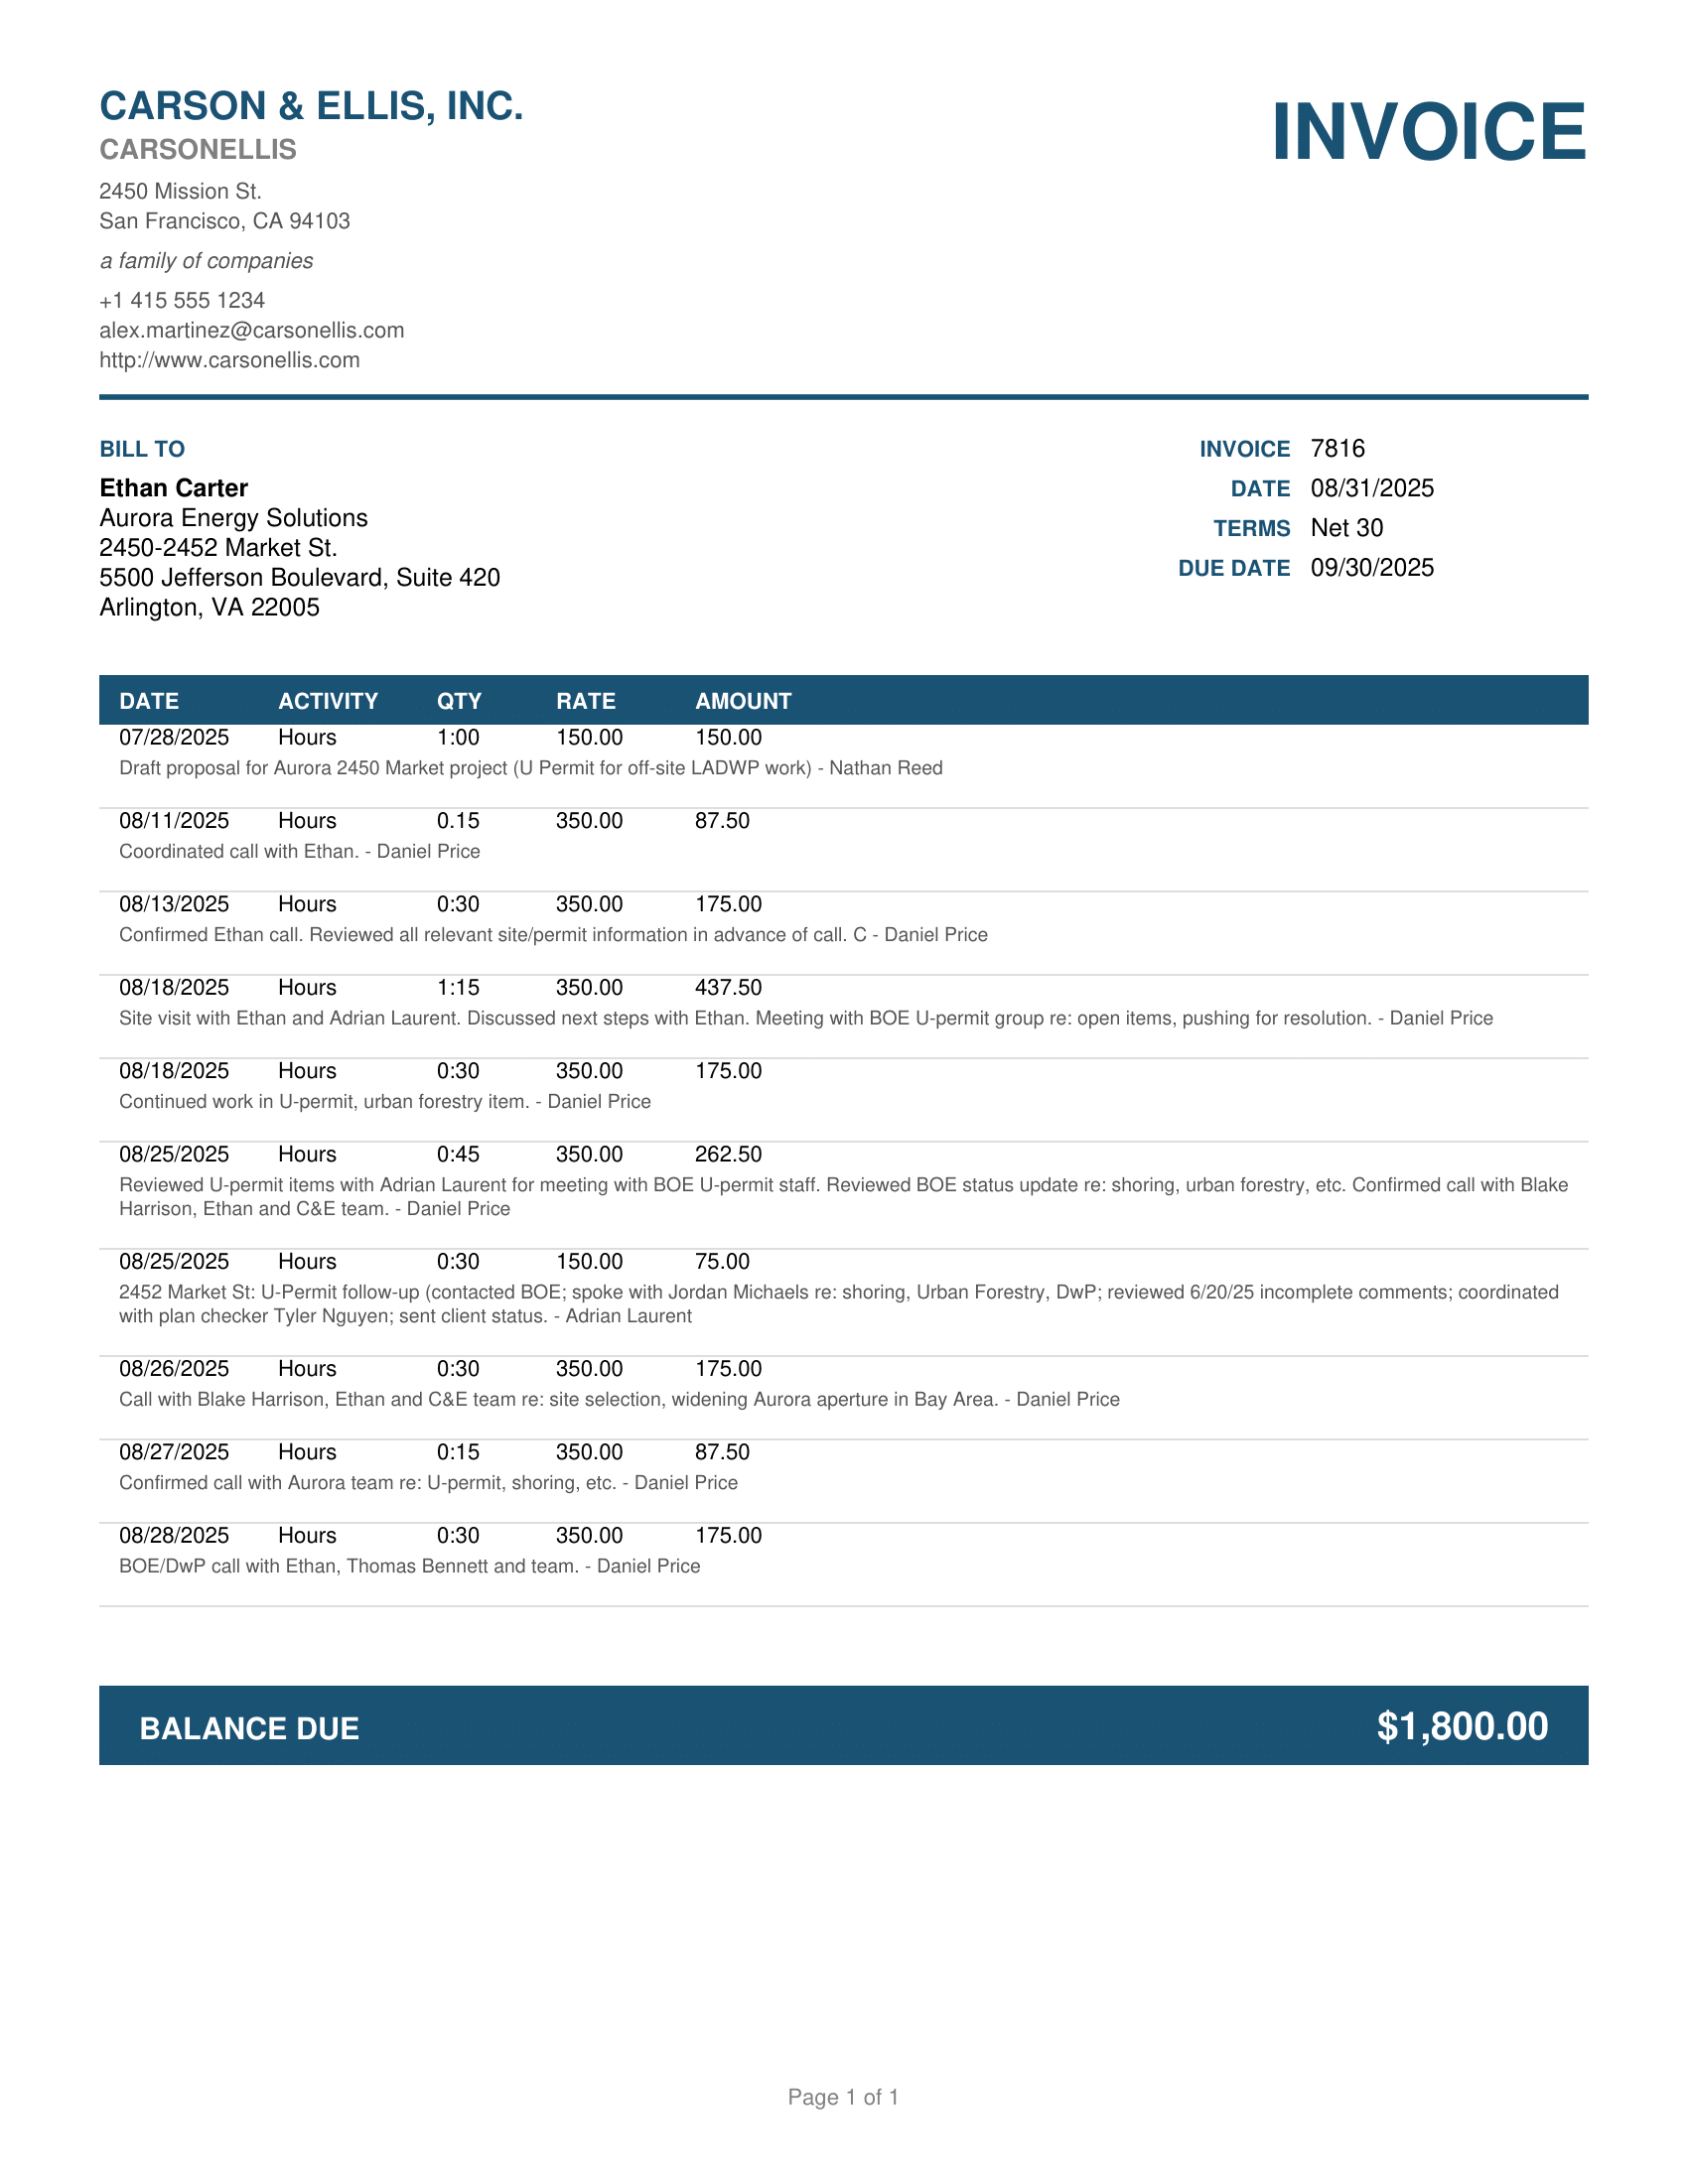

In [ ]:
from PIL import Image
from IPython.display import display

# Load the test invoice
invoice_path = "images/billing_typo.png"
img = Image.open(invoice_path)
display(img)

## The Extraction Task

We want to extract line items with this schema:

```json
{
  "description": "string",
  "quantity": "number | null",
  "unit_price": "number | null", 
  "amount": "number"
}
```

<a name="Compare"></a>
## Commercial LLM Extraction

Let's test with GPT-4o, Claude Opus 4.5, and Gemini 2.0 Flash.

In [ ]:
EXTRACTION_PROMPT = """Extract all line items from this invoice and return them as a JSON array.

Each line item must follow exactly this schema:
- description (string): Name or description of the item or service
- quantity (number | null): Quantity purchased. Use null if missing or not specified
- unit_price (number | null): Price per unit. Use null if not explicitly available
- amount (number): Total amount for the line item

Return ONLY the JSON array, no other text."""

In [5]:
import litellm

def encode_image(image_path: str) -> str:
    """Encode image to base64 for vision models."""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def extract_with_llm(model: str, image_path: str, prompt: str) -> dict:
    """Extract line items using a vision LLM."""
    image_data = encode_image(image_path)
    
    try:
        response = litellm.completion(
            model=model,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/png;base64,{image_data}"
                            }
                        }
                    ]
                }
            ],
            max_tokens=4096
        )
        
        content = response.choices[0].message.content
        # Parse JSON from response
        content = content.strip()
        if content.startswith("```"):
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
        return {"success": True, "data": json.loads(content)}
    except Exception as e:
        return {"success": False, "error": str(e)}

In [6]:
# Models to test
MODELS = {
    "GPT-5.2": "gpt-5.2-chat-latest",
    "Claude Opus 4.5": "claude-opus-4-5-20251101",
    "Gemini 2.0 Flash": "gemini/gemini-2.0-flash"
}

llm_results = {}

for name, model in MODELS.items():
    # Check if API key is configured
    if "gpt" in model and not os.environ.get("OPENAI_API_KEY"):
        print(f"⏭️  Skipping {name} (no API key)")
        continue
    if "claude" in model and not os.environ.get("ANTHROPIC_API_KEY"):
        print(f"⏭️  Skipping {name} (no API key)")
        continue
    if "gemini" in model and not os.environ.get("GEMINI_API_KEY"):
        print(f"⏭️  Skipping {name} (no API key)")
        continue
    
    print(f"🔄 Testing {name}...")
    result = extract_with_llm(model, invoice_path, EXTRACTION_PROMPT)
    llm_results[name] = result
    
    if result["success"]:
        print(f"✅ {name}: Extracted {len(result['data'])} line items")
    else:
        print(f"❌ {name}: {result['error']}")

🔄 Testing GPT-5.2...
✅ GPT-5.2: Extracted 10 line items
🔄 Testing Claude Opus 4.5...
✅ Claude Opus 4.5: Extracted 10 line items
⏭️  Skipping Gemini 2.0 Flash (no API key)


<a name="Validate"></a>
## Validate LLM Extractions

Let's check if the extracted quantities validate against the amounts.

In [7]:
def validate_line_items(line_items: list) -> list:
    """Validate that quantity × unit_price = amount for each line item."""
    errors = []
    
    for i, item in enumerate(line_items):
        qty = item.get("quantity")
        price = item.get("unit_price")
        amount = item.get("amount")
        
        if qty is not None and price is not None and amount is not None:
            expected = round(qty * price, 2)
            actual = round(amount, 2)
            
            if abs(expected - actual) > 0.01:  # Allow 1 cent tolerance
                errors.append({
                    "line": i + 1,
                    "description": item.get("description", "")[:50],
                    "quantity": qty,
                    "unit_price": price,
                    "expected_amount": expected,
                    "actual_amount": actual,
                    "difference": round(actual - expected, 2)
                })
    
    return errors

print("="*70)
print("VALIDATION RESULTS")
print("="*70)

for model_name, result in llm_results.items():
    if not result["success"]:
        continue
        
    print(f"\n📊 {model_name}")
    print("-"*50)
    
    errors = validate_line_items(result["data"])
    
    if errors:
        print(f"❌ Found {len(errors)} validation error(s):")
        for err in errors:
            print(f"   Line {err['line']}: {err['description']}")
            print(f"      {err['quantity']} × ${err['unit_price']} = ${err['expected_amount']}")
            print(f"      But invoice shows: ${err['actual_amount']}")
            print(f"      ⚠️  Difference: ${err['difference']}")
    else:
        print("✅ All line items validate correctly")

VALIDATION RESULTS

📊 GPT-5.2
--------------------------------------------------
❌ Found 1 validation error(s):
   Line 2: Hours - Coordinated call with Ethan. - Daniel Pric
      0.15 × $350.0 = $52.5
      But invoice shows: $87.5
      ⚠️  Difference: $35.0

📊 Claude Opus 4.5
--------------------------------------------------
❌ Found 1 validation error(s):
   Line 2: Hours - Coordinated call with Ethan. - Daniel Pric
      0.15 × $350.0 = $52.5
      But invoice shows: $87.5
      ⚠️  Difference: $35.0


## The Problem Revealed

Notice that line 2 has a validation error:

```
Line 2: Hours - Coordinated call with Ethan
   0.15 × $350.00 = $52.50
   But invoice shows: $87.50
   ⚠️  Difference: $35.00
```

The LLMs extracted `0.15` because that's what the document shows. But the correct value is `0:15` (15 minutes = 0.25 hours).

**0.25 × $350.00 = $87.50** ✓

This is a common Parsing/typing error in time-based billing documents.

<a name="Extract"></a>

---

## HyperAPI-Extract

HyperAPI-Extract doesn't just extract—it validates. When it sees a quantity that doesn't compute, it applies domain knowledge to correct it.

In [ ]:
import sys                                                                                                              
sys.path.insert(0, '/saif/hyperapi-sdk')                                                                                
from hyperapi import HyperAPIClient

# Initialize HyperAPI client
client = HyperAPIClient(
    api_key=os.environ.get("HYPERAPI_KEY"),
    base_url=os.environ.get("HYPERAPI_URL")
)

print("🔄 Processing with HyperAPI...")

# Step 1: Parse the document
parse_result = client.parse(invoice_path)
print(f"✅ Parsing complete: {len(parse_result['ocr'])} characters")

# Step 2: Extract with validation
extract_result = client.extract(parse_result["ocr"])
print(f"✅ Extraction complete")

🔄 Processing with HyperAPI...
✅ OCR complete: 2995 characters
✅ Extraction complete


In [30]:
# Display HyperAPI results
print("="*70)
print("HYPERAPI EXTRACTION RESULTS")
print("="*70)

hyperapi_data = extract_result.get("data", {})

print(f"\n📄 Invoice Number: {hyperapi_data.get('invoice_number')}")
print(f"📅 Invoice Date: {hyperapi_data.get('invoice_date')}")
print(f"💰 Total: {hyperapi_data.get('total')}")

print("\n📋 Line Items:")
print("-"*70)

line_items = hyperapi_data.get("line_items", [])
for i, item in enumerate(line_items, 1):
    print(f"\n{i}. {item.get('description', 'N/A')[:60]}")
    print(f"   Date: {item.get('date')}")
    print(f"   Quantity: {item.get('quantity')}")
    print(f"   Rate: ${item.get('unit_price')}")
    print(f"   Amount: ${item.get('amount')}")

HYPERAPI EXTRACTION RESULTS

📄 Invoice Number: None
📅 Invoice Date: 2025-08-31
💰 Total: None

📋 Line Items:
----------------------------------------------------------------------

1. Draft proposal for Aurora 2450 Market project (U Permit for 
   Date: None
   Quantity: 1.0
   Rate: $150.0
   Amount: $150.0

2. Coordinated call with Ethan.- Daniel Price
   Date: None
   Quantity: 0.25
   Rate: $350.0
   Amount: $87.5

3. Confirmed Ethan call. Reviewed all relevant site/permit info
   Date: None
   Quantity: 0.5
   Rate: $350.0
   Amount: $175.0

4. Site visit with Ethan and Adrian Laurent. Discussed next ste
   Date: None
   Quantity: 1.25
   Rate: $350.0
   Amount: $437.5

5. Continued work in U-permit, urban forestry item. - Daniel Pr
   Date: None
   Quantity: 0.5
   Rate: $350.0
   Amount: $175.0

6. Reviewed U-permit items with Adrian Laurent for meeting with
   Date: None
   Quantity: 0.75
   Rate: $350.0
   Amount: $262.5

7. 2452 Market St.: U-Permit follow-up (contacted BOE; s

In [31]:
# Validate HyperAPI extraction
print("\n" + "="*70)
print("HYPERAPI VALIDATION")
print("="*70)

def parse_time_quantity(qty_str):
    """Parse time-based quantity (e.g., '0:15' = 0.25 hours)."""
    if isinstance(qty_str, (int, float)):
        return float(qty_str)
    if isinstance(qty_str, str) and ':' in qty_str:
        parts = qty_str.split(':')
        hours = int(parts[0])
        minutes = int(parts[1])
        return hours + minutes / 60
    return float(qty_str)

all_valid = True
for i, item in enumerate(line_items, 1):
    qty = parse_time_quantity(item.get('quantity', 0))
    rate = float(item.get('unit_price', 0))
    amount = float(item.get('amount', 0))
    
    expected = round(qty * rate, 2)
    
    if abs(expected - amount) < 0.01:
        print(f"✅ Line {i}: {qty:.2f} hrs × ${rate:.2f} = ${expected:.2f}")
    else:
        print(f"❌ Line {i}: {qty:.2f} hrs × ${rate:.2f} = ${expected:.2f} (expected ${amount:.2f})")
        all_valid = False

print("\n" + "-"*50)
if all_valid:
    print("🎉 ALL LINE ITEMS VALIDATE CORRECTLY!")
else:
    print("⚠️  Some line items have validation errors")


HYPERAPI VALIDATION
✅ Line 1: 1.00 hrs × $150.00 = $150.00
✅ Line 2: 0.25 hrs × $350.00 = $87.50
✅ Line 3: 0.50 hrs × $350.00 = $175.00
✅ Line 4: 1.25 hrs × $350.00 = $437.50
✅ Line 5: 0.50 hrs × $350.00 = $175.00
✅ Line 6: 0.75 hrs × $350.00 = $262.50
✅ Line 7: 0.50 hrs × $150.00 = $75.00
✅ Line 8: 0.50 hrs × $350.00 = $175.00
✅ Line 9: 0.25 hrs × $350.00 = $87.50
✅ Line 10: 0.50 hrs × $350.00 = $175.00

--------------------------------------------------
🎉 ALL LINE ITEMS VALIDATE CORRECTLY!


## Summary: The Difference

| Aspect | Commercial LLMs | HyperAPI |
|--------|-----------------|----------|
| **Extraction** | Literal (extracts what it sees) | Validation-aware |
| **Error Handling** | Passes through errors | Detects & corrects |
| **Math Validation** | None | Cross-field checking |
| **Time Formats** | Treats `0.15` as decimal | Recognizes `0:15` pattern |
| **Reliability** | Prompt-dependent | Programmatic |

---

## The Takeaway

> **Stop prompting. Start programming.**

Prompts are:
- Brittle (small changes break them)
- Model-specific (what works for GPT may fail for Claude)
- Inconsistent (same prompt, different results)

HyperAPI provides:
- Deterministic extraction
- Built-in validation
- Domain-specific intelligence for financial documents

**Ready to try HyperAPI?** Get your API key at [apis.hyperbots.com](https://apis.hyperbots.com)

In [32]:
# Cleanup
client.close()